# Deep Learning for Astronomical Time Series Classification
**Transfer Learning from ETTh1 Forecasting to LSST Classification using Channel-Independent Architectures**

This notebook evaluates the performance of a pre-trained Deep Learning foundation model against a state-of-the-art baseline (ROCKET) on the LSST dataset. Our proposed approach leverages a Channel-Independent architecture to bridge the dimensional gap between the source domain (7 weather variables) and the target domain (6 astronomical light filters).

## 1. Environment setup & imports
Importing the necessary libraries (PyTorch, aeon, scikit-learn, seaborn), our custom project modules, and data.

In [9]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from aeon.transformations.collection.convolution_based import Rocket
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from tslearn.datasets import UCR_UEA_datasets

from src.dataset import LSSTClassificationDataset
from src.model import ClassificationModel, TimeSeriesEncoderCI
from src.preprocessing import encode_lsst_labels, scale_lsst_data

In [10]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [11]:
# Function to plot the normalized confusion matrix to visualize the performance of the classification models

def plot_normalized_cm(y_true, y_pred, class_names, title="Normalized Confusion Matrix", save_path=None):
    """
    Draw a normalized confusion matrix using Seaborn's heatmap.
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="white") 
    ax = sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                     xticklabels=class_names, yticklabels=class_names,
                     cbar_kws={'label': 'Proportion of True Class'},
                     vmin=0.0, vmax=1.0) 
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.ylabel('True Astronomical Class', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Astronomical Class', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()        
    plt.show()

## 2. Exploratory Data Analysis 

 We will specifically visualize the class distribution to highlight the severe imbalance (e.g., Class 90 heavily dominating minority classes like 53 or 64). This imbalance critically justifies our choice to evaluate the models based on the **Macro F1-score** rather than global accuracy.

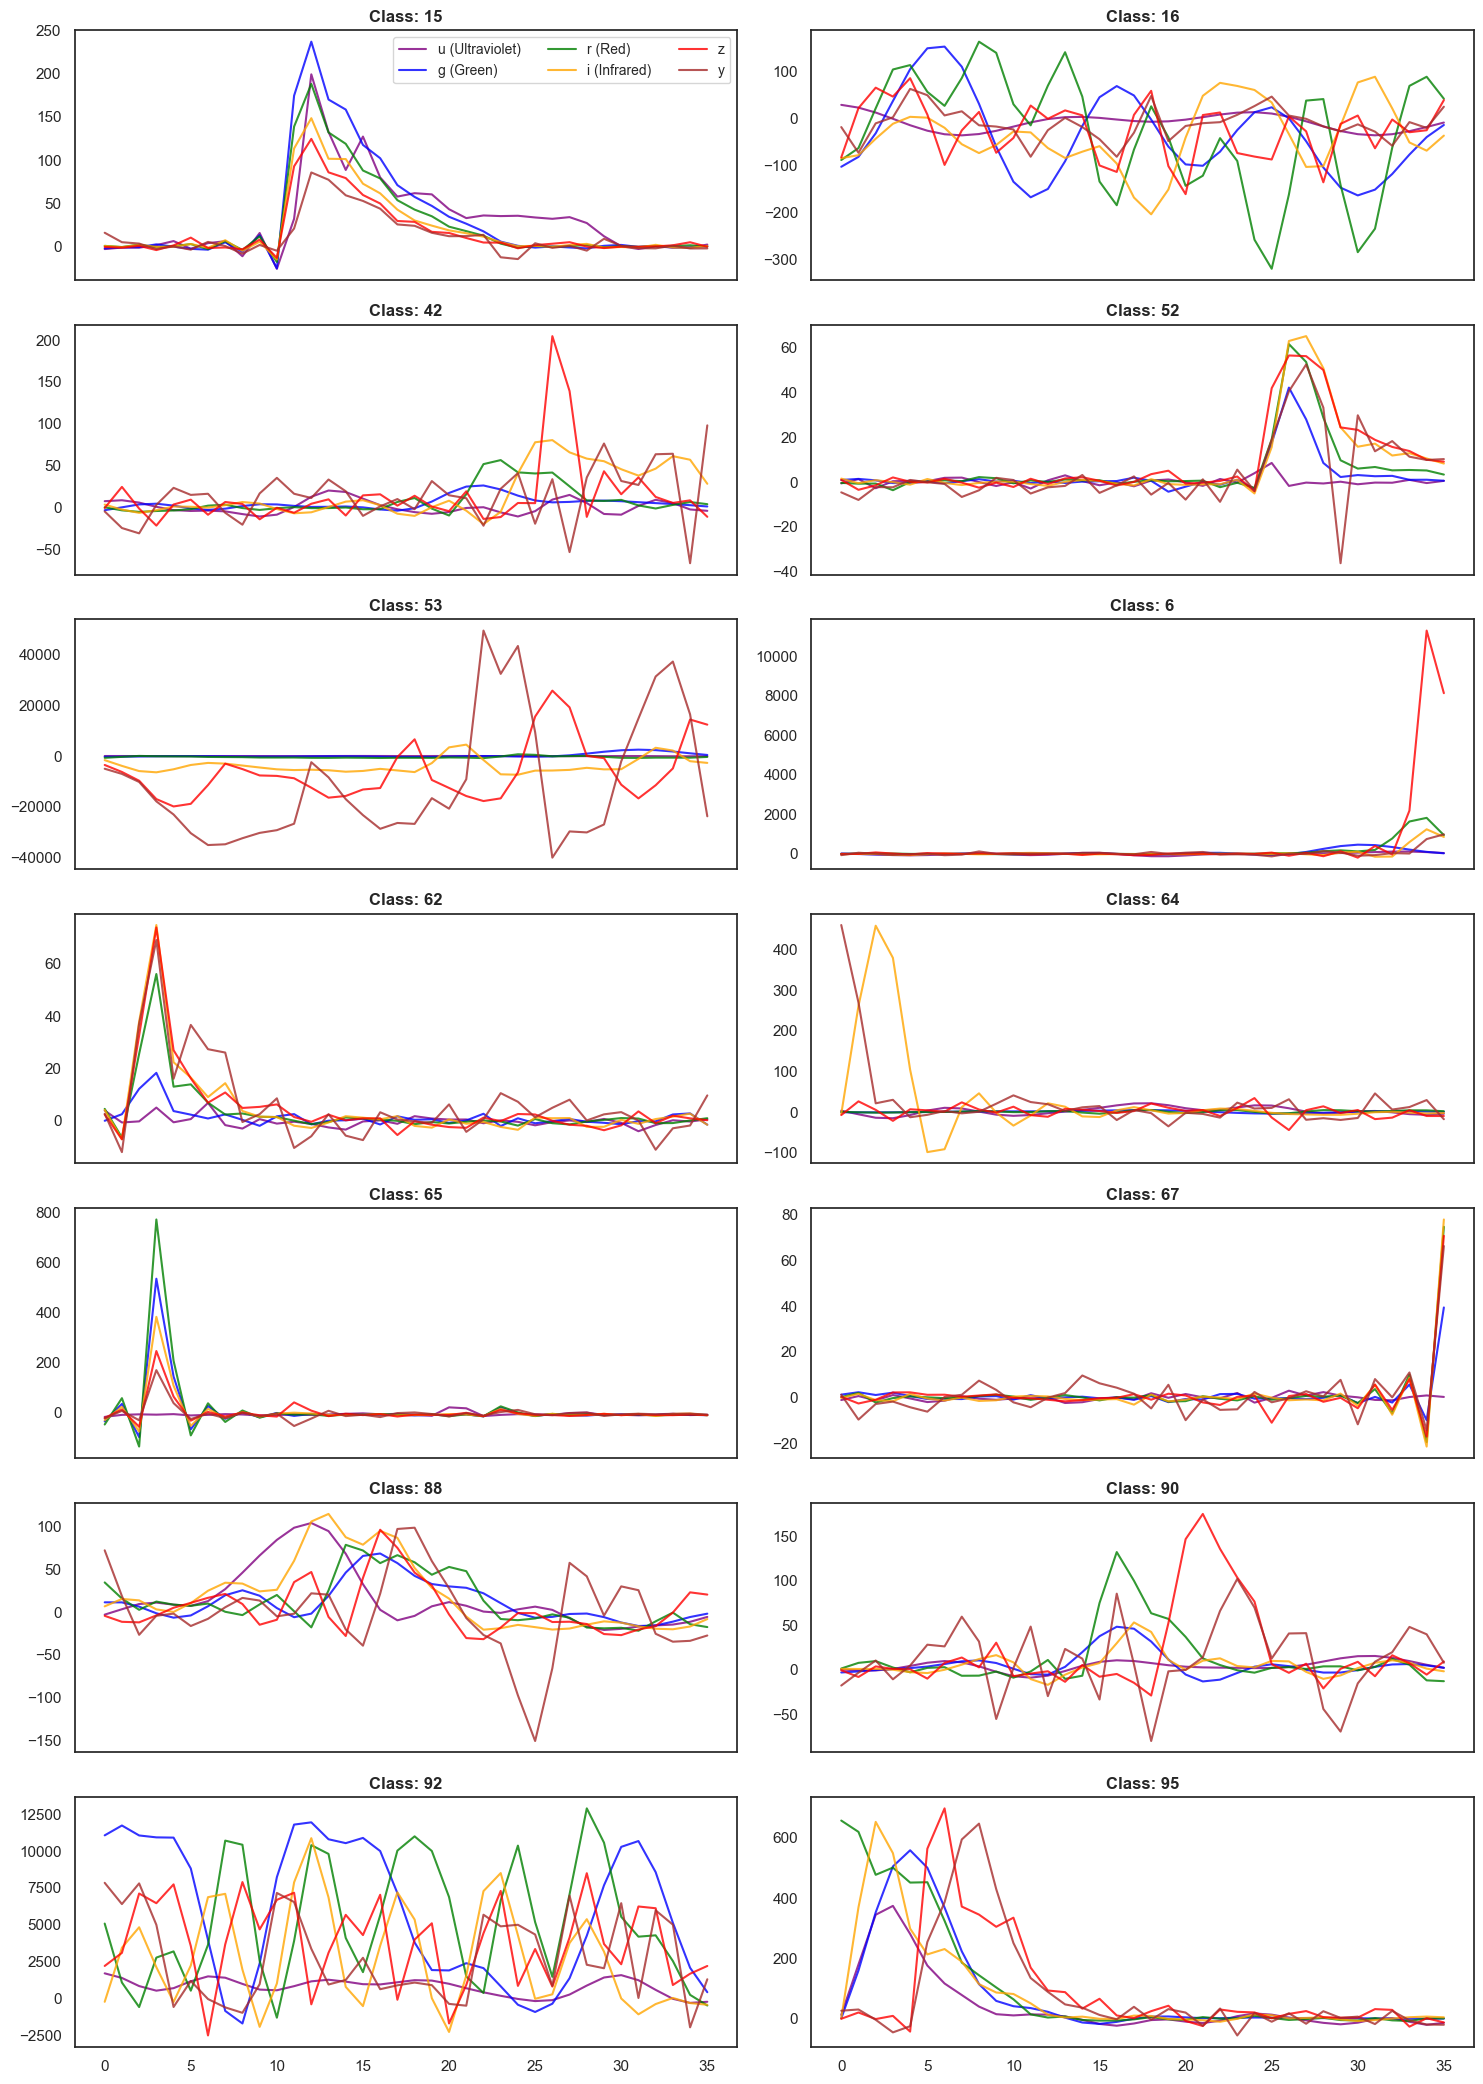

In [12]:
channel_names = ['u (Ultraviolet)', 'g (Green)', 'r (Red)', 'i (Infrared)', 'z', 'y']
colors = ['purple', 'blue', 'green', 'orange', 'red', 'brown']
classes = np.unique(y_train)
n_classes = len(classes)
n_channels = X_train.shape[2]

cols = 2
rows = math.ceil(n_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), sharex=True)
axes = axes.flatten()

for i, c in enumerate(classes):
    idx = np.where(y_train == c)[0][0]
    sample = X_train[idx]
    
    for ch in range(n_channels):
        axes[i].plot(sample[:, ch], label=f'{channel_names[ch]}', color=colors[ch], alpha=0.8)
        
    axes[i].set_title(f'Class: {c}', fontweight='bold')

    if i == 0:
        axes[i].legend(loc='upper right', fontsize='small', ncol=3)

for j in range(len(classes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\bapti\AppData\Local\Temp\ipykernel_21228\2929148008.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_classes_str, y=sorted_counts, palette="mako")


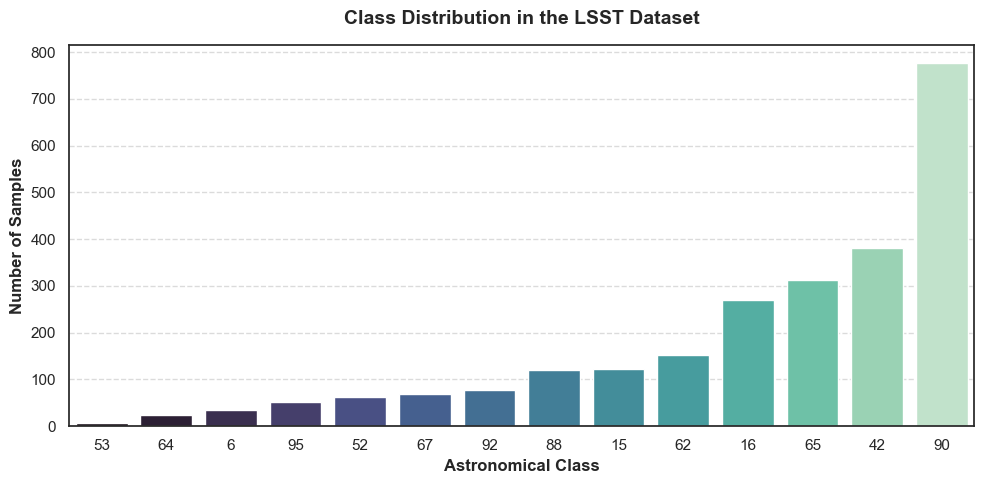

In [13]:
classes, counts = np.unique(y_train, return_counts=True)
n_classes = len(classes)
n_timestamps = X_train.shape[1]
n_channels = X_train.shape[2]

sorted_indices = np.argsort(counts)


sorted_classes = classes[sorted_indices]
sorted_counts = counts[sorted_indices]
sorted_classes_str = [str(c) for c in sorted_classes]
# -------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(x=sorted_classes_str, y=sorted_counts, palette="mako")

plt.title("Class Distribution in the LSST Dataset", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Astronomical Class", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Baseline : ROCKET
We evaluate ROCKET (RandOm Convolutional KErnel Transform) as our baseline. ROCKET is an exceptionally fast and accurate state-of-the-art model for time series classification. It extracts 10,000 random convolutional features, which are then classified using a Ridge Classifier.

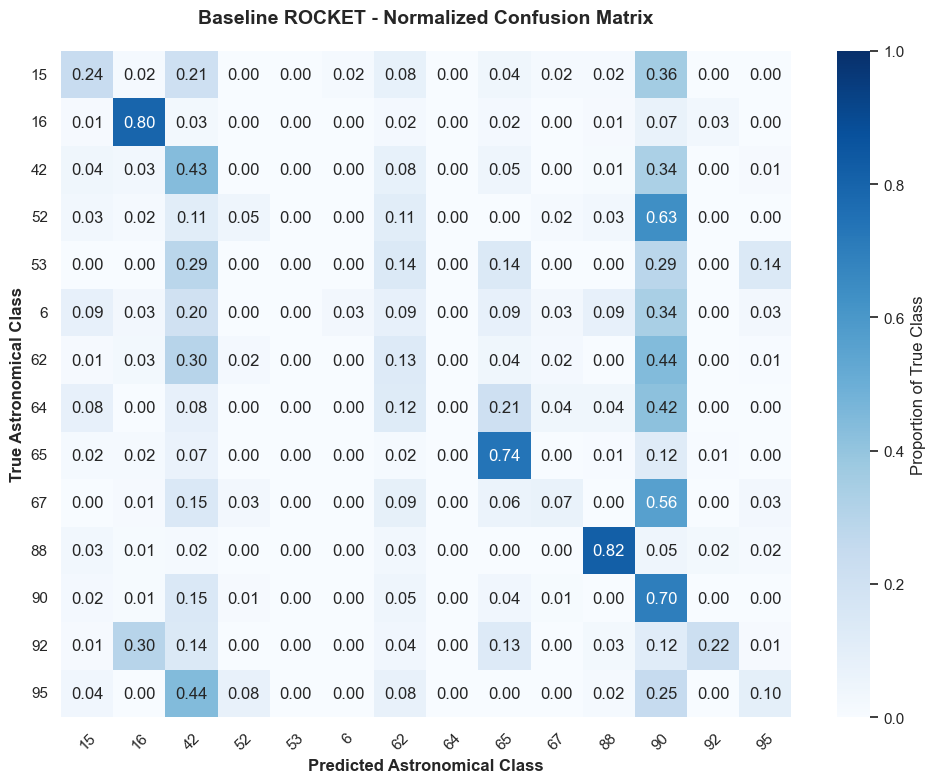

In [14]:
X_train_scaled, X_test_scaled = scale_lsst_data(X_train, X_test)
y_train_encoded, y_test_encoded, label_encoder = encode_lsst_labels(y_train, y_test)

X_train_aeon = np.transpose(X_train_scaled, (0, 2, 1))
X_test_aeon = np.transpose(X_test_scaled, (0, 2, 1))

rocket = Rocket(n_kernels=10000, random_state=42)
X_train_features = rocket.fit_transform(X_train_aeon)
X_test_features = rocket.transform(X_test_aeon)

classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier.fit(X_train_features, y_train_encoded)

y_pred_baseline = classifier.predict(X_test_features)

class_names = label_encoder.classes_
plot_normalized_cm(y_test_encoded, y_pred_baseline, class_names, title="Baseline ROCKET - Normalized Confusion Matrix", save_path="baseline_cm.pdf")

## 5. Channel-Independent Transfer Learning
In this section, we load our Deep Learning encoder, which was previously pre-trained on a forecasting task (ETTh1 dataset). By treating each input channel independently, the model seamlessly adapts from the 7-variable pre-training dataset to the 6-variable LSST dataset without requiring architectural changes.

C:\Users\bapti\AppData\Local\Temp\ipykernel_21228\1908231496.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dl.load_state_dict(torch.load("best_classification_mo

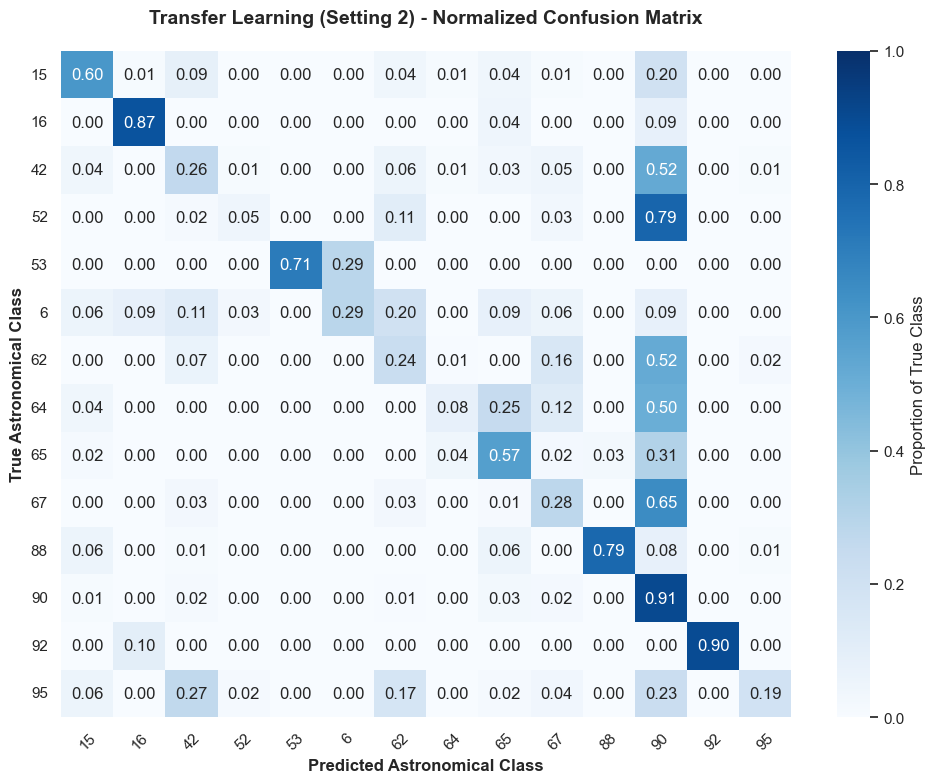

In [16]:
test_dataset = LSSTClassificationDataset(X_test_scaled, y_test_encoded)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

hidden_dim = 32
num_channels = X_test_scaled.shape[2]
num_classes = len(np.unique(y_test_encoded))

encoder = TimeSeriesEncoderCI(hidden_dim=hidden_dim)
model_dl = ClassificationModel(encoder, num_channels=num_channels, num_classes=num_classes)

model_dl.load_state_dict(torch.load("best_classification_model.pth"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dl.to(device)
model_dl.eval() 
y_pred_dl = []


with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        outputs = model_dl(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        y_pred_dl.extend(predicted.cpu().numpy())

plot_normalized_cm(
    y_true=y_test_encoded, 
    y_pred=y_pred_dl, 
    class_names=class_names, 
    title="Transfer Learning (Setting 2) - Normalized Confusion Matrix",
    save_path="cm_deep_learning.pdf"
)

## 6. Final Comparison: Per-Class F1-Score Analysis
While global metrics hide the reality of imbalanced datasets, comparing the F1-score for each class explicitly reveals the strengths of our approach. 
In the chart below, we compare the baseline and our model side-by-side. Notice the significant performance jump on minority classes, which mathematically explains our superior Macro F1-score.

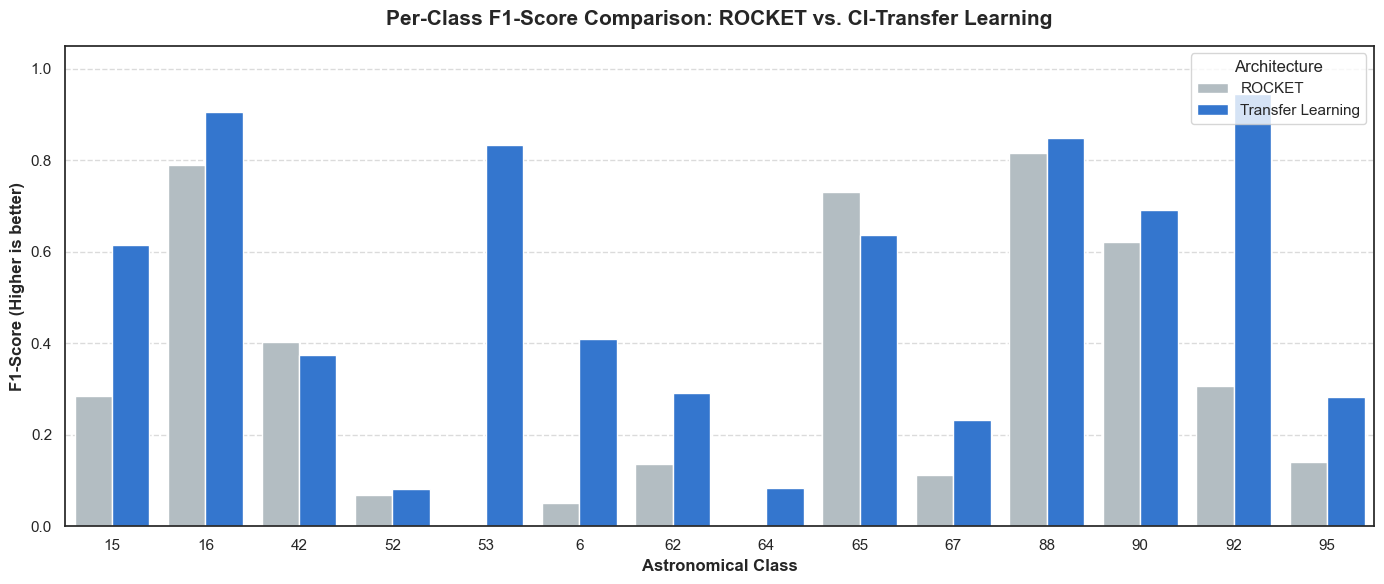

In [17]:
from sklearn.metrics import f1_score

f1_baseline = f1_score(y_test_encoded, y_pred_baseline, average=None)
f1_dl = f1_score(y_test_encoded, y_pred_dl, average=None)

classes_str = [str(c) for c in label_encoder.classes_]

df_compare = pd.DataFrame({
    'Class': classes_str * 2, 
    'F1-Score': np.concatenate([f1_baseline, f1_dl]),
    'Model': ['ROCKET'] * len(classes_str) + ['Transfer Learning'] * len(classes_str)
})


plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_compare, 
    x='Class', 
    y='F1-Score', 
    hue='Model', 
    palette=['#B0BEC5', '#1A73E8'] 
)
plt.title("Per-Class F1-Score Comparison: ROCKET vs. CI-Transfer Learning", fontsize=15, fontweight='bold', pad=15)
plt.ylabel("F1-Score (Higher is better)", fontsize=12, fontweight='bold')
plt.xlabel("Astronomical Class", fontsize=12, fontweight='bold')
plt.ylim(0, 1.05) # Bloque l'axe Y entre 0 et 1 (F1-score max)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Architecture', title_fontsize='12', fontsize='11', loc='upper right')
plt.tight_layout()
plt.show()